#### Предсказываем цену ноутбука

В папке лежит датасет laptop_prices, в котором содержатся сведения о ноутбуках, их характеристики и цены. Обучите модель линейной регрессии, которая будет предсказывать цену ноутбука по его характеристикам.

Придется хорошенько поработать с характеристиками: это *творческая* часть задания. Во-первых, надо привести их в машиночитаемый вид, а во-вторых, можно посмотреть, как они коррелируют друг с другом и не нужно ли кого-то из них дропнуть или наоборот. Не советую бездумно использовать OHE: некоторые признаки явно можно закодировать куда более оптимальным способом.

*Примечание*: без работы над фичами за все дз - **0 баллов**.

In [477]:
import pandas as pd

In [478]:
data = pd.read_csv('laptop_prices.csv')
data.head()

,Brand,Processor,RAM (GB),Storage,GPU,Screen Size (inch),Resolution,Battery Life (hours),Weight (kg),Operating System,Price ($)
0,Apple,AMD Ryzen 3,64,512GB SSD,Nvidia GTX 1650,17.3,2560x1440,8.9,1.42,FreeDOS,3997.07
1,Razer,AMD Ryzen 7,4,1TB SSD,Nvidia RTX 3080,14.0,1366x768,9.4,2.57,Linux,1355.78
2,Asus,Intel i5,32,2TB SSD,Nvidia RTX 3060,13.3,3840x2160,8.5,1.74,FreeDOS,2673.07
3,Lenovo,Intel i5,4,256GB SSD,Nvidia RTX 3080,13.3,1366x768,10.5,3.10,Windows,751.17
4,Razer,Intel i3,4,256GB SSD,AMD Radeon RX 6600,16.0,3840x2160,5.7,3.38,Linux,2059.83


In [127]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11768 entries, 0 to 11767
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Brand                 11768 non-null  object 
 1   Processor             11768 non-null  object 
 2   RAM (GB)              11768 non-null  int64  
 3   Storage               11768 non-null  object 
 4   GPU                   11768 non-null  object 
 5   Screen Size (inch)    11768 non-null  float64
 6   Resolution            11768 non-null  object 
 7   Battery Life (hours)  11768 non-null  float64
 8   Weight (kg)           11768 non-null  float64
 9   Operating System      11768 non-null  object 
 10  Price ($)             11768 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 1011.4+ KB


In [100]:
data.Processor.unique()

array(['AMD Ryzen 3', 'AMD Ryzen 7', 'Intel i5', 'Intel i3',
       'AMD Ryzen 9', 'AMD Ryzen 5', 'Intel i9', 'Intel i7'], dtype=object)

In [101]:
data.GPU.unique()

array(['Nvidia GTX 1650', 'Nvidia RTX 3080', 'Nvidia RTX 3060',
       'AMD Radeon RX 6600', 'Nvidia RTX 2060', 'AMD Radeon RX 6800',
       'Integrated'], dtype=object)

In [479]:
# поскольку моделей процессоров и видеокарт немного, я буду сравнивать их бенчмарки и видоизменять признак в числовой
# на сайте technical city есть сравнение видеокарт. каждой видеокарте присваивается рейтинг от 0 до 100. именно этот рейтинг я и буду присваивать каждой
# видеокарте в качестве значения в словаре. в дальнейшем этот словарь можно расширить новыми данными - удобно!
GPU_rate = {'Nvidia GTX 1650': 18.98, 'Nvidia RTX 3080': 60.58, 'Nvidia RTX 3060': 41.15,
       'AMD Radeon RX 6600': 36.40, 'Nvidia RTX 2060': 34.01, 'AMD Radeon RX 6800': 53.32,
       'Integrated': 10.00}
data['GPU'] = data['GPU'].map(GPU_rate)

In [480]:
CPU_rate = {'AMD Ryzen 3': 9.18, 'AMD Ryzen 7': 24.99, 'Intel i5': 24.23, 'Intel i3': 9.61,
       'AMD Ryzen 9': 43.94, 'AMD Ryzen 5': 18.71, 'Intel i9': 38.13, 'Intel i7': 33.19}
data['Processor'] = data['Processor'].map(CPU_rate)

In [359]:
# здесь ванхотить улучшает качество модели. но как же сомнительно это решение!!!
data = pd.get_dummies(data, columns=['Processor', 'GPU'])

In [264]:
data.Storage.unique()

array(['512GB SSD', '1TB SSD', '2TB SSD', '256GB SSD', '1TB HDD'],
      dtype=object)

In [481]:
data['SSD'] = data['Storage'].str.contains("SSD").astype(int)
# нам важно различие SSD и HDD

In [470]:
# но и объем важен! допустим, я люблю наскачивать фильмов себе на ноутбук и смотреть в самолете. мне лучше купить HDD на 1 ТБ чем SSD на 256
# нужно это учитывать
Storage_value = {'512GB SSD': 512, '1TB SSD': 1000, '2TB SSD': 2000, '256GB SSD': 256, '1TB HDD': 1000}
data['Storage'] = data['Storage'].map(Storage_value)

In [228]:
data.Resolution.unique()

array(['2560x1440', '1366x768', '3840x2160', '1920x1080'], dtype=object)

In [483]:
Resolution = {'2560x1440': 3, '1366x768': 1, '3840x2160': 4, '1920x1080': 2}
data['Resolution'] = data['Resolution'].map(Resolution)

In [370]:
# как оказалось, втупую ванхотить разрешение и память улучшает качество модели. но в прод такую модель не пустишь, если будет много столбцов
# или пустишь? типов разрешений немного - есть стандарты. то же самое с объемом и типом памяти. значит при добавлении новых значений кол-во столбцов будет
# увеличиваться, но не сильно
data = pd.get_dummies(data, columns=['Storage', 'Resolution'])

<Axes: >

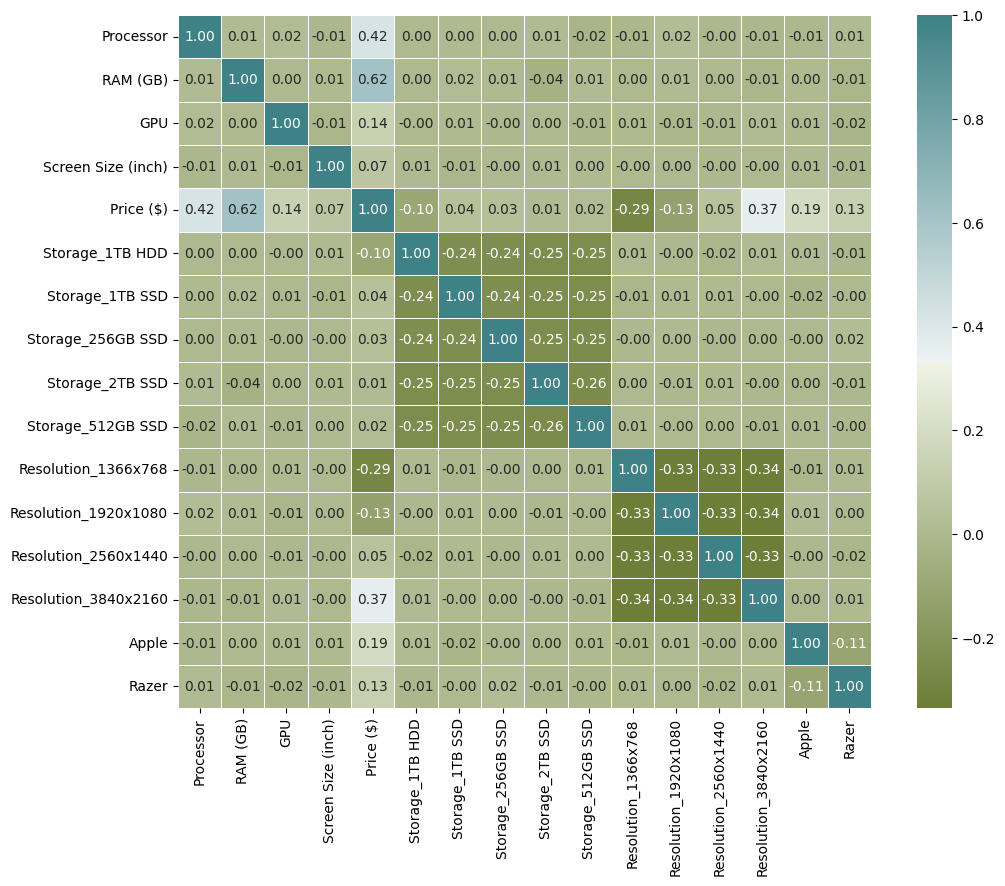

In [412]:
import seaborn as sns
import numpy as np
from matplotlib import pylab as plt

plt.figure(figsize=(12,9))

corr = data.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)

In [ ]:
# сильнее всего влияют характеристики: процессор, оперативная память, видеокарта (меньше), разрешение и, неожиданно, бренд apple и razer.
# они, конечно, считаются лучшими среди ноутбуков - значит, люди действительно смотрят на марку

In [484]:
# если оставлять эти 2 марки - результат сильно улучшается
data['Apple'] = data['Brand'].apply(lambda x: 1 if x == 'Apple' else 0)
data['Razer'] = data['Brand'].apply(lambda x: 1 if x == 'Razer' else 0)

In [485]:
# не влияют
data.drop(['Operating System', 'Brand', 'Battery Life (hours)', 'Weight (kg)'], axis=1, inplace=True)

In [ ]:
# можно добавить новые признаки в виде перемножения логически связанных характеристик

In [ ]:
data['RAM * GPU'] = data['GPU'] * data['RAM (GB)']
data['RAM * Processor'] = data['RAM (GB)'] * data['Processor']
data['GPU * CPU'] = data['GPU'] * data['Processor']
data['Screen_1'] = data['Screen Size (inch)'] * data['Resolution_1366x768']
data['Screen_2'] = data['Screen Size (inch)'] * data['Resolution_1920x1080']
data['Screen_3'] = data['Screen Size (inch)'] * data['Resolution_2560x1440']
data['Screen_4'] = data['Screen Size (inch)'] * data['Resolution_3840x2160']
data['FPS_1'] = data['GPU'] * data['Resolution_1366x768']
data['FPS_2'] = data['GPU'] * data['Resolution_1920x1080']
data['FPS_3'] = data['GPU'] * data['Resolution_2560x1440']
data['FPS_4'] = data['GPU'] * data['Resolution_3840x2160']

In [486]:
data

,Processor,RAM (GB),Storage,GPU,Screen Size (inch),Resolution,Price ($),SSD,Apple,Razer
0,9.18,64,2,18.98,17.3,3,3997.07,1,1,0
1,24.99,4,3,60.58,14.0,1,1355.78,1,0,1
2,24.23,32,4,41.15,13.3,4,2673.07,1,0,0
3,24.23,4,1,60.58,13.3,1,751.17,1,0,0
4,9.61,4,1,36.40,16.0,4,2059.83,1,0,1
...,...,...,...,...,...,...,...,...,...,...
11763,9.61,4,4,34.01,17.3,1,704.82,1,0,0
11764,9.61,4,4,53.32,16.0,1,775.59,1,0,0
11765,43.94,4,4,36.40,15.6,3,2789.46,1,0,1
11766,24.99,16,2,10.00,13.3,2,1067.13,1,0,0


In [500]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
X = data.drop('Price ($)', axis=1)
y = data['Price ($)']
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=111)
scaler = StandardScaler().fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)
regressor = LinearRegression()
regressor.fit(Xtrain, ytrain)
ypred_train = regressor.predict(Xtrain)
ypred_test = regressor.predict(Xtest)
print(mean_squared_error(ypred_test, ytest) ** 0.5)
print(mean_squared_error(ypred_train, ytrain) ** 0.5)

486.12029352199886
521.176533818722


In [501]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(Xtrain, ytrain)
pred_train = model.predict(Xtrain)
pred_test = model.predict(Xtest)
print(mean_squared_error(pred_test, ytest) ** 0.5, mean_squared_error(pred_train, ytrain) ** 0.5)

527.8310639295374 510.97083640652613


In [496]:
# итак, принимая во внимание потенциальную возможность добавления новых значений, я выбрала следующий формат обработки признаков:
import pandas as pd
data = pd.read_csv('laptop_prices.csv')
GPU_rate = {'Nvidia GTX 1650': 18.98, 'Nvidia RTX 3080': 60.58, 'Nvidia RTX 3060': 41.15,
       'AMD Radeon RX 6600': 36.40, 'Nvidia RTX 2060': 34.01, 'AMD Radeon RX 6800': 53.32,
       'Integrated': 10.00}
data['GPU'] = data['GPU'].map(GPU_rate)
CPU_rate = {'AMD Ryzen 3': 9.18, 'AMD Ryzen 7': 24.99, 'Intel i5': 24.23, 'Intel i3': 9.61,
       'AMD Ryzen 9': 43.94, 'AMD Ryzen 5': 18.71, 'Intel i9': 38.13, 'Intel i7': 33.19}
data['Processor'] = data['Processor'].map(CPU_rate)
data = pd.get_dummies(data, columns=['Storage', 'Resolution'])
data['Apple'] = data['Brand'].apply(lambda x: 1 if x == 'Apple' else 0)
data['Razer'] = data['Brand'].apply(lambda x: 1 if x == 'Razer' else 0)
data.drop(['Operating System', 'Brand', 'Battery Life (hours)', 'Weight (kg)'], axis=1, inplace=True)
data['RAM * GPU'] = data['GPU'] * data['RAM (GB)']
data['RAM * Processor'] = data['RAM (GB)'] * data['Processor']
data['GPU * CPU'] = data['GPU'] * data['Processor']
data['Screen_1'] = data['Screen Size (inch)'] * data['Resolution_1366x768']
data['Screen_2'] = data['Screen Size (inch)'] * data['Resolution_1920x1080']
data['Screen_3'] = data['Screen Size (inch)'] * data['Resolution_2560x1440']
data['Screen_4'] = data['Screen Size (inch)'] * data['Resolution_3840x2160']
data['FPS_1'] = data['GPU'] * data['Resolution_1366x768']
data['FPS_2'] = data['GPU'] * data['Resolution_1920x1080']
data['FPS_3'] = data['GPU'] * data['Resolution_2560x1440']
data['FPS_4'] = data['GPU'] * data['Resolution_3840x2160']
data

,Processor,RAM (GB),GPU,Screen Size (inch),Price ($),Storage_1TB HDD,Storage_1TB SSD,Storage_256GB SSD,Storage_2TB SSD,Storage_512GB SSD,...,RAM * Processor,GPU * CPU,Screen_1,Screen_2,Screen_3,Screen_4,FPS_1,FPS_2,FPS_3,FPS_4
0,9.18,64,18.98,17.3,3997.07,False,False,False,False,True,...,587.52,174.2364,0.0,0.0,17.3,0.0,0.00,0.0,18.98,0.00
1,24.99,4,60.58,14.0,1355.78,False,True,False,False,False,...,99.96,1513.8942,14.0,0.0,0.0,0.0,60.58,0.0,0.00,0.00
2,24.23,32,41.15,13.3,2673.07,False,False,False,True,False,...,775.36,997.0645,0.0,0.0,0.0,13.3,0.00,0.0,0.00,41.15
3,24.23,4,60.58,13.3,751.17,False,False,True,False,False,...,96.92,1467.8534,13.3,0.0,0.0,0.0,60.58,0.0,0.00,0.00
4,9.61,4,36.40,16.0,2059.83,False,False,True,False,False,...,38.44,349.8040,0.0,0.0,0.0,16.0,0.00,0.0,0.00,36.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11763,9.61,4,34.01,17.3,704.82,False,False,False,True,False,...,38.44,326.8361,17.3,0.0,0.0,0.0,34.01,0.0,0.00,0.00
11764,9.61,4,53.32,16.0,775.59,False,False,False,True,False,...,38.44,512.4052,16.0,0.0,0.0,0.0,53.32,0.0,0.00,0.00
11765,43.94,4,36.40,15.6,2789.46,False,False,False,True,False,...,175.76,1599.4160,0.0,0.0,15.6,0.0,0.00,0.0,36.40,0.00
11766,24.99,16,10.00,13.3,1067.13,False,False,False,False,True,...,399.84,249.9000,0.0,13.3,0.0,0.0,0.00,10.0,0.00,0.00


Итак, с масштабированием у нас получился результат 475. Столбцов у нас 27. При этом, при расширении датасета количество столбцов или вообще не увеличится (перечислены самые ходовые объемы памяти и разрешения экрана), или увеличится на несколько единиц.
Кажется, это компромисс между объемом и качеством.

In [499]:
# и совсем рофло-вариант с 15!!!! столбцами и неплохим результатом - 486
import pandas as pd
data = pd.read_csv('laptop_prices.csv')
GPU_rate = {'Nvidia GTX 1650': 18.98, 'Nvidia RTX 3080': 60.58, 'Nvidia RTX 3060': 41.15,
       'AMD Radeon RX 6600': 36.40, 'Nvidia RTX 2060': 34.01, 'AMD Radeon RX 6800': 53.32,
       'Integrated': 10.00}
data['GPU'] = data['GPU'].map(GPU_rate)
CPU_rate = {'AMD Ryzen 3': 9.18, 'AMD Ryzen 7': 24.99, 'Intel i5': 24.23, 'Intel i3': 9.61,
       'AMD Ryzen 9': 43.94, 'AMD Ryzen 5': 18.71, 'Intel i9': 38.13, 'Intel i7': 33.19}
data['Processor'] = data['Processor'].map(CPU_rate)
data['SSD'] = data['Storage'].str.contains("SSD").astype(int)
Storage_value = {'512GB SSD': 2, '1TB SSD': 3, '2TB SSD': 4, '256GB SSD': 1, '1TB HDD': 3}
data['Storage'] = data['Storage'].map(Storage_value)
Resolution = {'2560x1440': 3, '1366x768': 1, '3840x2160': 4, '1920x1080': 2}
data['Resolution'] = data['Resolution'].map(Resolution)
data['Apple'] = data['Brand'].apply(lambda x: 1 if x == 'Apple' else 0)
data['Razer'] = data['Brand'].apply(lambda x: 1 if x == 'Razer' else 0)
data.drop(['Operating System', 'Brand', 'Battery Life (hours)', 'Weight (kg)'], axis=1, inplace=True)
data['RAM * GPU'] = data['GPU'] * data['RAM (GB)']
data['RAM * Processor'] = data['RAM (GB)'] * data['Processor']
data['GPU * CPU'] = data['GPU'] * data['Processor']
data['Screen_1'] = data['Screen Size (inch)'] * data['Resolution']
data['FPS_1'] = data['GPU'] * data['Resolution']
data

,Processor,RAM (GB),Storage,GPU,Screen Size (inch),Resolution,Price ($),SSD,Apple,Razer,RAM * GPU,RAM * Processor,GPU * CPU,Screen_1,FPS_1
0,9.18,64,2,18.98,17.3,3,3997.07,1,1,0,1214.72,587.52,174.2364,51.9,56.94
1,24.99,4,3,60.58,14.0,1,1355.78,1,0,1,242.32,99.96,1513.8942,14.0,60.58
2,24.23,32,4,41.15,13.3,4,2673.07,1,0,0,1316.80,775.36,997.0645,53.2,164.60
3,24.23,4,1,60.58,13.3,1,751.17,1,0,0,242.32,96.92,1467.8534,13.3,60.58
4,9.61,4,1,36.40,16.0,4,2059.83,1,0,1,145.60,38.44,349.8040,64.0,145.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11763,9.61,4,4,34.01,17.3,1,704.82,1,0,0,136.04,38.44,326.8361,17.3,34.01
11764,9.61,4,4,53.32,16.0,1,775.59,1,0,0,213.28,38.44,512.4052,16.0,53.32
11765,43.94,4,4,36.40,15.6,3,2789.46,1,0,1,145.60,175.76,1599.4160,46.8,109.20
11766,24.99,16,2,10.00,13.3,2,1067.13,1,0,0,160.00,399.84,249.9000,26.6,20.00
